# C5.4 Networks — Mini-project (Double Copying All-or-none model)
#### _(Candidate 1509403)_

In this notebook, we look at a modified all-or-none model, investigating whether adding a more powerful copying mechanism creates a more representative model for empirical dense networks. In particular, we want to see whether the newly christened "All-or-none Double Copying Model" fulfills that commonly seen "shrinking diameter" assumption (as found in the paper of Leskovec et al. [2]). 

As outlined in the RevTex submission, instead of looking at a Bernoulli r.v. $X_1 \sim B(p)$, we look at a binomial r.v. $X_2 \sim Bin(2, p)$. At each time step, we have: 
<br>•	With probability $(1-p)^2$, no copying occurs.
<br>•	With probability $2p(1-p)$ we have copying as before. 
<br>•	We introduce double copying, with probability $p^2$. This adds edges from $v^*$ to the target $v$, to the target's neighbours $x_i$, and the target's secondary neighbours (neighbours of all the $x_i$).
<br> Below is the implementation of this model.

In [1]:
import scipy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx
import scipy.special as sp
rng = np.random.default_rng(seed=None)

In [2]:
import pickle
import os

In [3]:
#function to create a new edge, occurs each timestep
def newEdgeAONMod(G, p, rand1, rand2):
    if G == None: #if no graph, we begin with G_1, the graph at t = 0
        G = nx.Graph()
        G.add_node(1)
    n = G.number_of_nodes()
    
    if rand1 == None: #note that when generating a graph G_{n_max}, it is faster to generate all the rv first, so I added this functionality
        rand1 = rng.binomial(1, p, size=(1, 1)) #chooses whether copying occurs via Bernoulli rv, probability p
    if rand2 == None: 
        rand2 = rng.binomial(1, p, size=(1, 1)) 
        
    t = np.random.choice(G.nodes()) #chooses target
    G.add_node(n + 1)
    
    if (rand1 + rand2) == 1:
        neighbours = list(G.neighbors(t))
        for nb in neighbours:
            G.add_edge(n + 1, nb) #adds edges to neighbours if copying occurs
    elif (rand1 + rand2) == 2:
        neighbours = list(G.neighbors(t))
        for nb in neighbours:
            secondnb = list(G.neighbors(nb))
            for snb in secondnb:
                G.add_edge(n + 1, snb)
            G.add_edge(n + 1, nb) #adds edges to neighbours if copying occurs           
    G.add_edge(n + 1,t) #adds edge to the target afterwards
    return G

In [4]:
#function to generate a new graph G_n, with t = n - 1 (graph at t=0 is G_1)
def aonGenMod(G, p, t):
    randArray = rng.binomial(1, p, size=(t, 2)) #generates random variables beforehand
    for i in range(0, t):
        newEdgeAONMod(G, p, randArray[i][0], randArray[i][1]) #simulates t timesteps of the model
    return G

In [5]:
#generates the default graph
G_init = nx.Graph()
G_init.add_node(1)

Example graph for $p = 0.2, t = 20$. We can see that even for low $p$ values, that our graph is dense (we expect the phase transition in edge number to occur at a $p$ value lower than this.

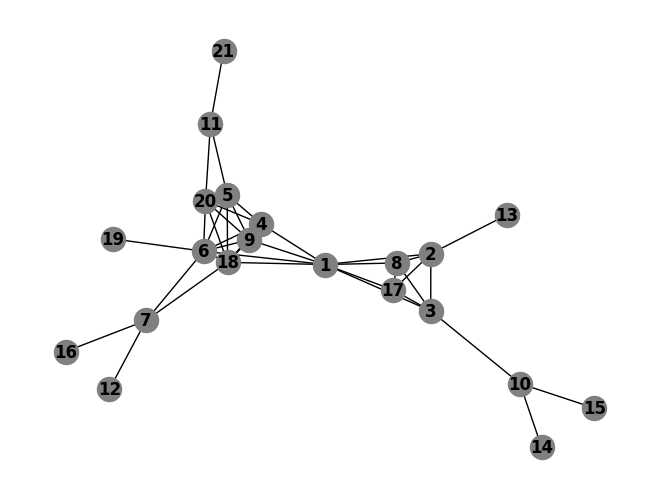

In [6]:
p = 0.2
t = 20
G_example = aonGenMod(G_init.copy(), p, t)
nx.draw(G_example, with_labels=True, font_weight='bold', node_color='grey')

In [7]:
pValues = [i * 0.02 for i in range(0, 31)]
t = 1000
sims = 1
#for naming conventions
pstr = str(p)[2:]
order = int(np.floor(np.log10(abs(t))))
lead = str(t)[0]
tstr = str(lead) + "e" + str(order)

for p in pValues:
    newpath = f"AON\\Modified\\{p}" 
    if not os.path.exists(newpath):
        os.makedirs(newpath)

for p in pValues:
    #for naming conventions
    pstr = str(p)[2:]
    order = int(np.floor(np.log10(abs(t))))
    lead = str(t)[0]
    tstr = str(lead) + "e" + str(order)         
    for i in range(1, sims + 1):
        filename = f"AON\\Modified\\{p}\\aonp{pstr}t{tstr}s{i}.pkl"     
        #only creates the graphs if the file does not already exist
        if not os.path.exists(filename):
            G = aonGenMod(G_init.copy(), p, 1000)
            with open(filename, "wb") as f:
                pickle.dump(G, f, protocol=pickle.HIGHEST_PROTOCOL)

Given that edge number and therefore mean degree rely on the neighbourhoods of second-neighbours, it is harder to find a proper closed form for their recurrence relations. However, we found a rough recurrence relation, which when solved, gives the dense regime to be when $p > p_c$. <br>
The critical $p_c = 1 - \frac{\sqrt{3}}{2} \approx 0.134$, so we'll expect to see the mean degree constant wrt time for $p < p_c$ (sparse regime), and then the mean degree gains its n-dependence back for $p > p_c$. <br> <br>
Note that this model is significantly more computationally intensive than the previous AON model, so we only have one simulation for each $p$ value, and we limit the graph generation for up to $p = 0.6$.

In [8]:
#plots edge number against p for varying values of n, meant to show how edge number grows for different p
#uses saved graphs (generated above), and finds edge number for their subgraphs
#since nodes are labelled as they are added, we take the first n nodes and find edge number for those
#so we can see how edge number

#we look to calculate the mean degree and shortest path length for varying p
#we try to find where mean degree becomes non-stationary, to detect where the dense regime begins
#from there, we aim to look at shortest path length for varying p, and aim to find where it starts falling for increasing n

#initialisation for pValues and tValues we are testing over
pValues = [i * 0.02 for i in range(0, 31)]
t = 1000
tValues = [30, 100, 300, 1000]
sims = 1
edgeFullResults = {}
edgeResults = {}

#for naming conventions of saved graphs
order = int(np.floor(np.log10(abs(t))))
lead = str(t)[0]
tstr = str(lead) + "e" + str(order)

for t in tValues:
    subNodes = [i for i in range(1, t + 1)] #defines the first n nodes for a subgraph
    #initialises each dictionary entry at time t as a dictionary for pValues
    edgeFullResults[t] = {}
    edgeResults[t] = {}
    for p in pValues:
        #for naming conventions
        pstr = str(p)[2:]
        edgeArray = []
        for i in range(1, sims + 1):
            #opens saved g
            with open(f"AON\\Modified\\{p}\\aonp{pstr}t{tstr}s{i}.pkl", "rb") as f:
                G = pickle.load(f)
            Gsub = G.subgraph(subNodes) #gives subgraph, effectively showing G at an earlier time
            edgeArray.append(nx.number_of_edges(Gsub)) #calculates edge number for given t, p
        #saves results (and mean) for given t, p 
        edgeFullResults[t][p] = edgeArray
        edgeResults[t][p] = np.nanmean(edgeArray)

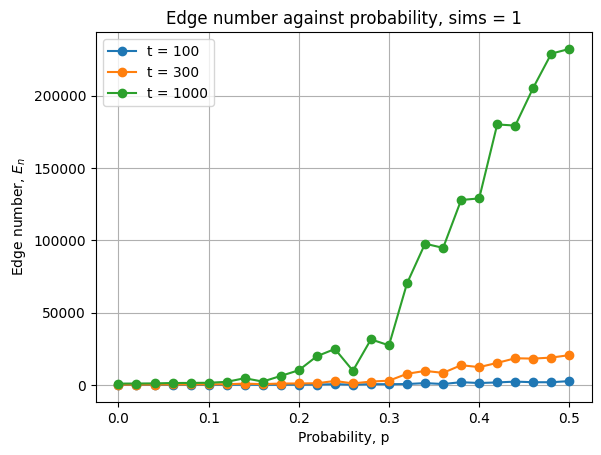

In [9]:
#edge number for p < 1/2, sparse regime, E_n grows linearly
#close to p = 1/2, the constant tends to infinity so it diverges from the linear growth
means = {}
stds = {}
med = {}
lower = {}
upper = {}

pValues = [i * 0.02 for i in range(0, 26)]
tValues = [100, 300, 1000]
#simply makes a list that fixes t, and finds the mean/std/med for each p
for t in tValues:
    means[t] = []
    stds[t] = []
    med[t] = []
    for p in pValues:
        values = edgeFullResults[t][p]
        means[t].append(np.nanmean(values))
        stds[t].append(np.nanstd(values))
        med[t].append(np.nanmedian(values))

    means[t] = np.array(means[t])
    stds[t] = np.array(stds[t])
    med[t] = np.array(med[t])

    #we also calculate 1 std away from the mean so we can graph it
    lower[t] = means[t] - stds[t]
    upper[t] = means[t] + stds[t]

for t in tValues:
    plt.plot(pValues, means[t], marker='o', label=f"t = {t}")
    #plt.plot(pValues, med[t], marker='o', label='med')
    #plt.fill_between(pValues, lower[t], upper[t], alpha=0.25) #, label='±1 std dev')
plt.xlabel("Probability, p")
plt.ylabel("Edge number, $E_n$")
plt.title(f"Edge number against probability, sims = {sims}")
plt.grid(True)
plt.legend()
plt.show()

In [10]:
#mean degree calculation
pValues = [i * 0.02 for i in range(0, 31)]
tValues = [30, 100, 300, 1000]
degResults = {}
for t in tValues:
    degResults[t] = {}
    for p in pValues:
        degResults[t][p] = np.zeros(sims) 
        for i in range(0, sims):
            degResults[t][p][i] = 2 * edgeFullResults[t][p][i] / (t + 1)

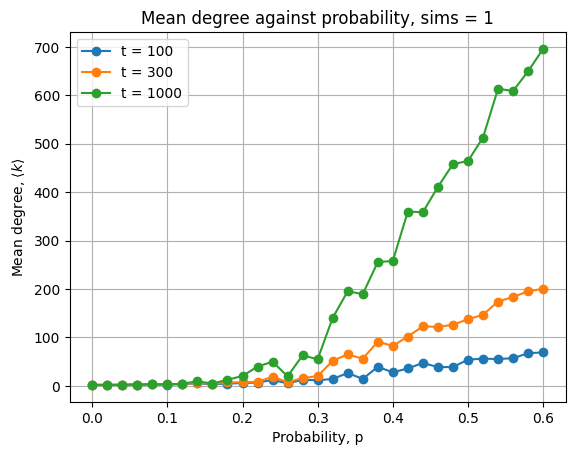

In [11]:
#mean degree for p < 1/2, stationary
means = {}
stds = {}
med = {}
lower = {}
upper = {}

pValues = [i * 0.02 for i in range(0, 31)]
tValues = [100, 300, 1000]
#simply makes a list that fixes t, and finds the mean/std/med for each p
for t in tValues:
    means[t] = []
    stds[t] = []
    med[t] = []
    for p in pValues:
        values = degResults[t][p]
        means[t].append(np.nanmean(values))
        stds[t].append(np.nanstd(values))
        med[t].append(np.nanmedian(values))

    means[t] = np.array(means[t])
    stds[t] = np.array(stds[t])
    med[t] = np.array(med[t])

    #we also calculate 1 std away from the mean so we can graph it
    lower[t] = means[t] - stds[t]
    upper[t] = means[t] + stds[t]

for t in tValues:
    plt.plot(pValues, means[t], marker='o', label=f"t = {t}")
    #plt.plot(pValues, med[t], marker='o', label='med')
    plt.fill_between(pValues, lower[t], upper[t], alpha=0.25) #, label='±1 std dev')
plt.xlabel("Probability, p")
plt.ylabel("Mean degree, $⟨k⟩$")
plt.title(f"Mean degree against probability, sims = {sims}")
plt.grid(True)
plt.legend()
plt.show()

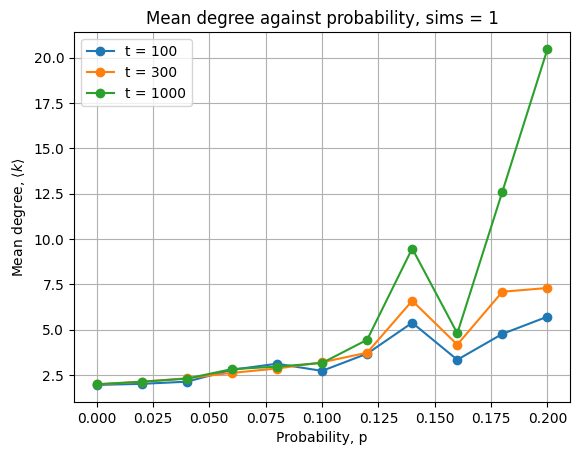

In [12]:
#mean degree for p < 1/2, stationary
means = {}
stds = {}
med = {}
lower = {}
upper = {}

pValues = [i * 0.02 for i in range(0, 11)]
tValues = [100, 300, 1000]
#simply makes a list that fixes t, and finds the mean/std/med for each p
for t in tValues:
    means[t] = []
    stds[t] = []
    med[t] = []
    for p in pValues:
        values = degResults[t][p]
        means[t].append(np.nanmean(values))
        stds[t].append(np.nanstd(values))
        med[t].append(np.nanmedian(values))

    means[t] = np.array(means[t])
    stds[t] = np.array(stds[t])
    med[t] = np.array(med[t])

    #we also calculate 1 std away from the mean so we can graph it
    lower[t] = means[t] - stds[t]
    upper[t] = means[t] + stds[t]

for t in tValues:
    plt.plot(pValues, means[t], marker='o', label=f"t = {t}")
    #plt.plot(pValues, med[t], marker='o', label='med')
    plt.fill_between(pValues, lower[t], upper[t], alpha=0.25) #, label='±1 std dev')
plt.xlabel("Probability, p")
plt.ylabel("Mean degree, $⟨k⟩$")
plt.title(f"Mean degree against probability, sims = {sims}")
plt.grid(True)
plt.legend()
plt.show()

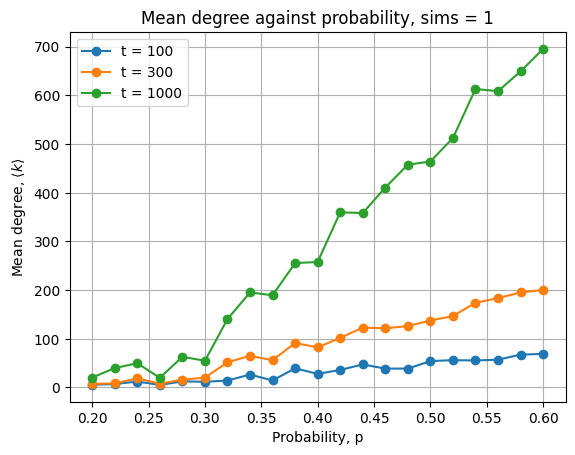

In [13]:
#mean degree for p < 1/2, stationary
means = {}
stds = {}
med = {}
lower = {}
upper = {}

pValues = [i * 0.02 for i in range(10, 31)]
tValues = [100, 300, 1000]
#simply makes a list that fixes t, and finds the mean/std/med for each p
for t in tValues:
    means[t] = []
    stds[t] = []
    med[t] = []
    for p in pValues:
        values = degResults[t][p]
        means[t].append(np.nanmean(values))
        stds[t].append(np.nanstd(values))
        med[t].append(np.nanmedian(values))

    means[t] = np.array(means[t])
    stds[t] = np.array(stds[t])
    med[t] = np.array(med[t])

    #we also calculate 1 std away from the mean so we can graph it
    lower[t] = means[t] - stds[t]
    upper[t] = means[t] + stds[t]

for t in tValues:
    plt.plot(pValues, means[t], marker='o', label=f"t = {t}")
    #plt.plot(pValues, med[t], marker='o', label='med')
    plt.fill_between(pValues, lower[t], upper[t], alpha=0.25) #, label='±1 std dev')
plt.xlabel("Probability, p")
plt.ylabel("Mean degree, $⟨k⟩$")
plt.title(f"Mean degree against probability, sims = {sims}")
plt.grid(True)
plt.legend()
plt.show()

While the data suggests that our critical value for $p_c \approx 0.13$ is correct, since we have only run one simulation, we can only be fairly certain. 
Now, we focus on looking at the mean shortest path length and therefore diameter. We will generate 10 simulations for $p = 0.3$.

In [14]:
#calculates mean, med and std of [sims] simulations. 
#This works by creating an array, no_t, that denotes the amount of a given data type at each timestep 
#in each simulation. Then, we find the mean/med/std at the given time t, and add these to a new array.
def aonMeanStdCalc(results, samples, sims):
    no_t = []
    meanArr = []
    medArr = []
    stdDev = []
    for i in range(0, samples):
        no_t = []
        for j in range(0, sims):
            no_t.append(results[j][i]) #creates the array at time t
        meanArr.append(np.average(no_t))
        medArr.append(np.median(no_t))
        stdDev.append(np.std(no_t))
    return meanArr, medArr, stdDev

In [15]:
pValues = [0.3]
t = 1000
sims = 10
#for naming conventions
pstr = str(p)[2:]
order = int(np.floor(np.log10(abs(t))))
lead = str(t)[0]
tstr = str(lead) + "e" + str(order)

for p in pValues:
    newpath = f"AON\\Modified\\{p}" 
    if not os.path.exists(newpath):
        os.makedirs(newpath)

for p in pValues:
    #for naming conventions
    pstr = str(p)[2:]
    order = int(np.floor(np.log10(abs(t))))
    lead = str(t)[0]
    tstr = str(lead) + "e" + str(order)
    for i in range(1, sims + 1):
        G = aonGenMod(G_init.copy(), p, 1000)
        with open(f"AON\\Modified\\{p}\\aonp{pstr}t{tstr}s{i}.pkl", "wb") as f:
            pickle.dump(G, f, protocol=pickle.HIGHEST_PROTOCOL)

In [16]:
#similar to the code to calculate the clique number over time (see documentation)
#takes samples of path length at regular intervals of [sampleTime]
p = 0.3
pValues = [p]
t = 1000
sims = 10
pathFullResults = {}
pathResults = {}
pathMedResults = {}

samples = 20
sampleTime = 50

for p in pValues:
    #for naming conventions
    pstr = str(p)[2:]
    order = int(np.floor(np.log10(abs(t))))
    lead = str(t)[0]
    tstr = str(lead) + "e" + str(order)
    pathArray = []
    #loads graph for each simulation
    for i in range(0, sims):
        with open(f"AON\\Modified\\{p}\\aonp{pstr}t{tstr}s{i+1}.pkl", "rb") as f:
            G = pickle.load(f)
        Gsub = G.subgraph(1)
        subNodes = [1]
        pathArray = [0]
        for j in range(0, samples):
            for k in range(j * sampleTime + 2, (j + 1) * sampleTime + 2):
                subNodes.append(k)
            Gsub = G.subgraph(subNodes)
            #finds average shortest path length for each pair of nodes in Gsub
            pathArray.append(nx.average_shortest_path_length(Gsub))
        pathFullResults[i] = pathArray

In [17]:
pathMeanArr, pathMedArr, pathStdArr = aonMeanStdCalc(pathFullResults, samples + 1, sims)
pathResults[p] = pathMeanArr
pathMedResults[p] = pathMedArr

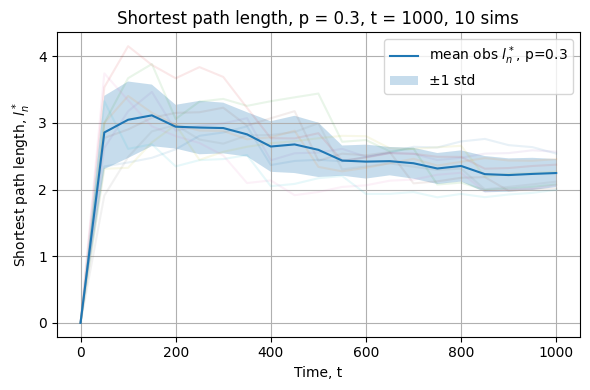

In [18]:
#code to plot the path length against the expected path length
#note that since we derive path length up to a constant, then the "normalisation step" nails down the 
#constant rather than a prefactor
plt.figure(figsize=(6,4))
pValues = [0.3]
#plots the path length against t for each simulation
for i in range(0, sims):
    plt.plot([i * sampleTime for i in range(0, samples + 1)], pathFullResults[i], alpha = 0.1)  
#plots the mean shortest path length
for p in pValues:
    plt.plot([i * sampleTime for i in range(0, samples + 1)], pathResults[p], label=f"mean obs $l_n^*$, p={p}")  
#plots the predicted path length, determining constant c using the mean shortest path length
p = 0.3
x = np.linspace(10, 1000, 100)
y = 2*(1-p)*np.log(x)
c = pathMeanArr[-1] - y[-1]
y += c
#plt.plot(x, y, label=f"predicted")
upper = np.array(pathMeanArr) + np.array(pathStdArr)
lower = np.array(pathMeanArr) - np.array(pathStdArr)
plt.fill_between(np.linspace(0, 1000, samples + 1), lower, upper, alpha=0.25, label='±1 std')
plt.xlabel("Time, t")
plt.ylabel("Shortest path length, $l_n^*$")
plt.title(f"Shortest path length, p = {p}, t = {t}, {sims} sims")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

As hypothesised, we find that the shortest path length does decline for large $n$! Hence, for further investigation of dense networks, one may want to consider adding secondary or further linking processes to a model to better replicate the shrinking diameter observation.